##### I. Setup

In [ ]:
import os
from pyspark.sql import SparkSession, DataFrame
from google.colab import files
from pyspark.sql.functions import *
from pyspark.sql.types import TimestampType
from functools import reduce
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyspark.sql.window import Window
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [ ]:
!pip uninstall -y pyspark pyspark-connect dataproc-spark-connect

Found existing installation: pyspark 4.0.4
Uninstalling pyspark-4.0.4:
  Successfully uninstalled pyspark-4.0.4


In [ ]:
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless -qq
!pip install -q pyspark==3.5.1

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
!pip uninstall -y pyspark
!pip install -q pyspark==4.0.4

Found existing installation: pyspark 3.5.1
Uninstalling pyspark-3.5.1:
  Successfully uninstalled pyspark-3.5.1


In [ ]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [ ]:
!java -version

openjdk version "17.0.20" 2026-07-21
OpenJDK Runtime Environment (build 17.0.20+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.20+8-1-24.04-Ubuntu, mixed mode, sharing)


In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("DataCleaning")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
files= files.upload()

Saving OnlineRetail.csv to OnlineRetail (1).csv


In [ ]:
# create a data file within working directory to save csv files
from pathlib import Path
Path("data_files").mkdir(exist_ok=True)

In [ ]:
# create a plot file within working directory to save plot
from pathlib import Path
Path("/content/drive/MyDrive/Dinh Thi Thanh Hang- Portfolio/Data Viz").mkdir(exist_ok=True)

##### II. Load data

In [ ]:
df = spark.read.csv("OnlineRetail.csv", header=True, inferSchema=True)
df.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
only showing top 5 rows


##### III. Data Profiling, Anomaly Detection, and Data Cleaning

###### 3.1 Check the number of columns and rows

In [ ]:
# Check the number of columns and rows
print("Number of columns: ", len(df.columns))
print("Number of rows: ", df.count())

Number of columns:  8
Number of rows:  541909


###### 3.2 Abnormal 1: Check and Correct data type

In [ ]:
# Check schema
df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
# Convert datatype of InvoiceDate to timestamp
df_cleaned = df.withColumn("InvoiceDate", to_timestamp("InvoiceDate", "M/d/yyyy H:mm"))

# Re-check schema
df_cleaned.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



###### 3.3 Abnormal 2: Check and handle missing values

In [ ]:
# Check for missing values in original data
missing_values = df_cleaned.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df_cleaned.columns
])
missing_values.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135080|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



- `Description`: 1,454 --> remove since it is hard to guess the product description
- `CustomerID`: 135,080 --> might keep them, change `null` value into `Unknown`

In [ ]:
df_cleaned.filter(df.Description.isNull()).select("StockCode").distinct().count()

960

In [ ]:
missing_stockcodes = (
    df_cleaned
    .filter(col("Description").isNull())
    .select("StockCode")
    .distinct()
    .rdd.flatMap(lambda x: x)
    .collect()
)

In [ ]:
# Delete the null values in Description
df_cleaned = df_cleaned.filter(df_cleaned.Description.isNotNull())

In [ ]:
# flag customers with null customer id as Unidentified
df_cleaned= df_cleaned.withColumn("Customer_Type",
                                  when(col("CustomerID").isNull(),"Anonymous").otherwise("Identified"))

###### 3.4 Abnormal 3: Check and handle duplicate rows

In [ ]:
# Check the number of duplicate rows
duplicate_count = (
    df_cleaned.count()
    - df_cleaned.dropDuplicates().count()
)

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [ ]:
# Drop duplicate rows
df_cleaned = df_cleaned.dropDuplicates()

In [ ]:
# Re-check the number of duplicate rows
duplicate_count = df_cleaned.count() - df_cleaned.dropDuplicates().count()
print("Number of duplicate rows: ", duplicate_count)

Number of duplicate rows:  0


###### 3.5 Abnormal 4: Handle negative Quantity and UnitPrice

**Check the number of cancelled order:**

The InvoiceNo starts with C (has negative Quantity)

In [ ]:
from pyspark.sql import functions as F

# Cancelled orders
cancel = df_cleaned.filter(F.col("InvoiceNo").startswith("C"))

# Negative quantity but NOT cancelled
neg_qty_non_cancel = df_cleaned.filter(
    (~F.col("InvoiceNo").startswith("C")) &
    (F.col("Quantity") < 0)
)

# Negative unit price
neg_price = df_cleaned.filter(F.col("UnitPrice") < 0)

In [ ]:
print("Cancelled orders:", cancel.count())
print("Negative qty but NOT cancelled:", neg_qty_non_cancel.count())
print("Negative unit price:", neg_price.count())

Cancelled orders: 9251
Negative qty but NOT cancelled: 474
Negative unit price: 2


In [ ]:
from pyspark.sql import functions as F

df_cleaned = df_cleaned.filter(
        (~F.col("InvoiceNo").startswith("C")) &
        (F.col("Quantity") > 0) &
        (F.col("UnitPrice") > 0)
    )
print(df_cleaned.count())

524878


In [ ]:
print("Number Of Cancelled Orders", cancel.count())

Number Of Cancelled Orders 9251


###### 3.6 Abnormal 5: Identify abnormal `StockCode` - `Description` pairs that are not actual products

**Check abnormal StockCodes**

In [ ]:
excluded_stockcodes = ["POST", "DOT", "M", "C2", "BANK CHARGES","S", "B", "AMAZONFEE",
                       "gift_0001_10", "gift_0001_20","gift_0001_30","gift_0001_40","gift_0001_50"]

# Identify rows with exclued StockCode
df_excluded = df_cleaned.filter(col("StockCode").isin(excluded_stockcodes))

# Show distinct excluded StockCode - Description pairs
df_excluded.select("StockCode", "Description").distinct().show(truncate=False)

+------------+----------------------------------+
|StockCode   |Description                       |
+------------+----------------------------------+
|POST        |POSTAGE                           |
|DOT         |DOTCOM POSTAGE                    |
|gift_0001_40|Dotcomgiftshop Gift Voucher �40.00|
|C2          |CARRIAGE                          |
|gift_0001_30|Dotcomgiftshop Gift Voucher �30.00|
|BANK CHARGES|Bank Charges                      |
|M           |Manual                            |
|AMAZONFEE   |AMAZON FEE                        |
|gift_0001_50|Dotcomgiftshop Gift Voucher �50.00|
|gift_0001_20|Dotcomgiftshop Gift Voucher �20.00|
|S           |SAMPLES                           |
|gift_0001_10|Dotcomgiftshop Gift Voucher �10.00|
|B           |Adjust bad debt                   |
+------------+----------------------------------+



**Handle abnormal `StockCode` and `Description` pairs that are not actual products**

In [ ]:
df_cleaned = df_cleaned.filter(~col("StockCode").isin(excluded_stockcodes))

In [ ]:
# Re-check the abnormal stock code
df_excluded = df_cleaned.filter(col("StockCode").isin(excluded_stockcodes))
df_excluded.select("StockCode", "Description").distinct().show(truncate=False)

+---------+-----------+
|StockCode|Description|
+---------+-----------+
+---------+-----------+



##### IV. Data Cleaning results

In [ ]:
# The number of rows before cleaning
rows_before_cleaning = df.count()
print(f"Number of rows before cleaning: {rows_before_cleaning}")

Number of rows before cleaning: 541909


In [ ]:
# Check the number of rows after cleaning
rows_after_cleaning = df_cleaned.count()
print(f"Number of rows after cleaning: {rows_after_cleaning}")

Number of rows after cleaning: 522541


In [ ]:
df_cleaned.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Customer_Type|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|   536367|    22749|FELTCRAFT PRINCES...|       8|2010-12-01 08:34:00|     3.75|     13047|United Kingdom|   Identified|
|   536367|    84969|BOX OF 6 ASSORTED...|       6|2010-12-01 08:34:00|     4.25|     13047|United Kingdom|   Identified|
|   536368|    22913|RED COAT RACK PAR...|       3|2010-12-01 08:34:00|     4.95|     13047|United Kingdom|   Identified|
|   536381|    22644|CERAMIC CHERRY CA...|       1|2010-12-01 09:41:00|     1.45|     15311|United Kingdom|   Identified|
|   536402|    22837|HOT WATER BOTTLE ...|      36|2010-12-01 11:22:00|     4.25|     15513|United Kingdom|   Identified|
+---------+---------+---

In [ ]:
from pyspark.sql import functions as F

total_rows = df_cleaned.count()

unknown_count = df_cleaned.filter(
    F.col("Customer_Type") == "Anonymous"
).count()
unknown_pct = unknown_count / total_rows * 100

print(f"Unknown rows: {unknown_count:,}")
print(f"Percentage: {unknown_pct:.2f}%")

Unknown rows: 131,388
Percentage: 25.14%


In [ ]:
from pyspark.sql import functions as F

# Revenue at row/item level
df_revenue = df_cleaned.withColumn(
    "Revenue",
    F.col("Quantity") * F.col("UnitPrice")
)

# Aggregate to order level first
df_order = (
    df_revenue
    .groupBy("Customer_Type", "InvoiceNo")
    .agg(
        F.sum("Revenue").alias("Order_Revenue"),
        F.sum("Quantity").alias("Items")
    )
)

# Compare customer types
customer_type_summary = (
    df_order
    .groupBy("Customer_Type")
    .agg(
        F.countDistinct("InvoiceNo").alias("Orders"),
        F.sum("Order_Revenue").alias("Total_Revenue"),
        F.avg("Order_Revenue").alias("AOV"),
        F.avg("Items").alias("Avg_Items_Per_Order")
    )
    .orderBy("Customer_Type")
)

customer_type_summary.show(truncate=False)

+-------------+------+------------------+------------------+-------------------+
|Customer_Type|Orders|Total_Revenue     |AOV               |Avg_Items_Per_Order|
+-------------+------+------------------+------------------+-------------------+
|Anonymous    |1371  |1509994.2299999993|1101.381641137855 |306.05470459518597 |
|Identified   |18402 |8737227.64300003  |474.79771997609123|279.4145745027714  |
+-------------+------+------------------+------------------+-------------------+



In [ ]:
df_time = df_revenue.withColumn(
    "InvoiceDate",
    F.to_timestamp("InvoiceDate", "M/d/yyyy H:mm")
)

df_time.groupBy("Customer_Type").agg(
    F.min("InvoiceDate").alias("First_Order_Date"),
    F.max("InvoiceDate").alias("Last_Order_Date")
).show(truncate=False)

+-------------+-------------------+-------------------+
|Customer_Type|First_Order_Date   |Last_Order_Date    |
+-------------+-------------------+-------------------+
|Anonymous    |2010-12-01 14:32:00|2011-12-09 10:26:00|
|Identified   |2010-12-01 08:26:00|2011-12-09 12:50:00|
+-------------+-------------------+-------------------+



In [ ]:
df_monthly = (
    df_time
    .withColumn("Month", F.date_format("InvoiceDate", "yyyy-MM"))
    .groupBy("Month", "Customer_Type")
    .agg(
        F.countDistinct("InvoiceNo").alias("Orders"),
        F.sum("Revenue").alias("Revenue")
    )
    .orderBy("Month", "Customer_Type")
)

df_monthly.show(100, truncate=False)

+-------+-------------+------+------------------+
|Month  |Customer_Type|Orders|Revenue           |
+-------+-------------+------+------------------+
|2010-12|Anonymous    |156   |210441.35000000006|
|2010-12|Identified   |1394  |565199.5600000008 |
|2011-01|Anonymous    |98    |107697.32999999999|
|2011-01|Identified   |983   |562682.9100000005 |
|2011-02|Anonymous    |101   |65506.28          |
|2011-02|Identified   |992   |442293.58999999985|
|2011-03|Anonymous    |128   |106689.65999999997|
|2011-03|Identified   |1312  |583143.8499999999 |
|2011-04|Anonymous    |96    |60937.10999999999 |
|2011-04|Identified   |1139  |454440.8810000004 |
|2011-05|Anonymous    |124   |80710.50999999997 |
|2011-05|Identified   |1544  |659242.4900000005 |
|2011-06|Anonymous    |135   |84294.05999999992 |
|2011-06|Identified   |1390  |653264.9199999997 |
|2011-07|Anonymous    |131   |96615.54999999996 |
|2011-07|Identified   |1321  |591603.7910000001 |
|2011-08|Anonymous    |72    |88702.11999999997 |


### Summary Of Findings:
- **Identified customers are the core revenue driver, contributing ~85% of total revenue and 93% of all orders.** Their order volume also grew strongly toward late 2011, peaking at 2,642 orders in November.

- **Anonymous customers are much smaller in volume but place significantly higher-value orders:** their AOV is ~£1,101, more than 2× that of identified customers (£475), while items per order are only ~10% higher (306 vs. 279).

- This suggests that the higher Anonymous AOV is likely driven by **higher-priced products or larger quantities of specific items**, rather than simply more items per order. Anonymous revenue also spiked sharply in November 2011 despite relatively low order volume, warranting further investigation.


##### V. Feature Engineering

###### 5.1 Create Recency, Frequency, and Monetary (RFM) features

Convert InvoiceDate to DateType

In [ ]:
df_final= df_cleaned.filter(F.col('Customer_Type')=='Identified')

In [ ]:
from pyspark.sql.functions import col, to_date

# Convert InvoiceDate from string to DateType
df_fe = df_final.withColumn("InvoiceDate", to_timestamp(col("InvoiceDate"), "M/d/yyyy H:mm"))
df_fe.printSchema()
df_fe.show()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- Customer_Type: string (nullable = false)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Customer_Type|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|   536367|    22749|FELTCRAFT PRINCES...|       8|2010-12-01 08:34:00|     3.75|     13047|United Kingdom|   Identified|
|   536367|    84969|BOX OF 6 ASSORTED...|       6|2010-12-01 08:34:00|     4.25|     13047|United Kingdom|   Identified|
|  

In [ ]:
# Get the max date of the dataset
max_date = df_fe.agg(max("InvoiceDate")).collect()[0][0]
max_date

datetime.datetime(2011, 12, 9, 12, 50)

In [ ]:
# Calculate recency
recency_df = df_fe.groupBy("CustomerID").agg(
    datediff(lit(max_date), max("InvoiceDate")).alias("Recency")
)
recency_df.show()

+----------+-------+
|CustomerID|Recency|
+----------+-------+
|     17420|     50|
|     16503|    106|
|     15727|     16|
|     17389|      0|
|     15447|    330|
|     14450|    180|
|     13623|     30|
|     13285|     23|
|     16339|    284|
|     14570|    280|
|     16386|     28|
|     16861|     59|
|     18024|    152|
|     15100|    333|
|     16916|     23|
|     12471|      2|
|     14514|     61|
|     16500|      4|
|     12626|     23|
|     18161|     15|
+----------+-------+
only showing top 20 rows


In [ ]:
from pyspark.sql import functions as F

In [ ]:
# Calculate frequency (number of transactions per customer)
frequency_df = df_fe.groupBy("CustomerID").agg(
    F.countDistinct("InvoiceNo").alias("Frequency")
)
frequency_df.show()

+----------+---------+
|CustomerID|Frequency|
+----------+---------+
|     17389|       34|
|     14450|        3|
|     15727|        7|
|     13285|        4|
|     14570|        2|
|     16503|        4|
|     17420|        3|
|     15447|        1|
|     13623|        5|
|     18024|        2|
|     16861|        2|
|     16339|        1|
|     16386|        2|
|     15619|        1|
|     15790|        1|
|     16574|        1|
|     13832|        1|
|     15957|        1|
|     17679|        2|
|     12940|        2|
+----------+---------+
only showing top 20 rows


In [ ]:
# Calculate Monetary (Total money spent by customer)
monetary_df = df_fe.withColumn("TotalPrice", col("Quantity") * col("UnitPrice")) \
    .groupBy("CustomerID") \
    .agg(round(sum("TotalPrice"), 3).alias("Monetary"))
monetary_df.show()

+----------+--------+
|CustomerID|Monetary|
+----------+--------+
|     16503| 1431.93|
|     13285| 2709.12|
|     18024|  389.78|
|     17389|31833.68|
|     15727| 5159.06|
|     14570|  217.21|
|     13623|  727.74|
|     14450|  483.25|
|     15447|  155.17|
|     16339|   94.05|
|     17420|  598.83|
|     16386|  302.57|
|     16861|  173.76|
|     12940|  899.69|
|     15957|  428.89|
|     16574|  451.44|
|     13832|    52.2|
|     15790|  218.75|
|     17679| 1992.11|
|     15619|   336.4|
+----------+--------+
only showing top 20 rows


In [ ]:
# Join all RFM features
dfs = [recency_df, frequency_df, monetary_df]
rfm_df = reduce(lambda df1, df2: df1.join(df2, "CustomerID"), dfs)
rfm_df.show()

+----------+-------+---------+--------+
|CustomerID|Recency|Frequency|Monetary|
+----------+-------+---------+--------+
|     17389|      0|       34|31833.68|
|     14450|    180|        3|  483.25|
|     15727|     16|        7| 5159.06|
|     13285|     23|        4| 2709.12|
|     14570|    280|        2|  217.21|
|     16503|    106|        4| 1431.93|
|     17420|     50|        3|  598.83|
|     15447|    330|        1|  155.17|
|     13623|     30|        5|  727.74|
|     18024|    152|        2|  389.78|
|     16861|     59|        2|  173.76|
|     16339|    284|        1|   94.05|
|     16386|     28|        2|  302.57|
|     15619|     10|        1|   336.4|
|     15790|     10|        1|  218.75|
|     16574|     71|        1|  451.44|
|     13832|     19|        1|    52.2|
|     15957|     31|        1|  428.89|
|     17679|     52|        2| 1992.11|
|     12940|     54|        2|  899.69|
+----------+-------+---------+--------+
only showing top 20 rows


In [ ]:
from pyspark.sql.functions import mean

rfm_df.select(
    mean("Recency").alias("Mean_Recency"),
    mean("Frequency").alias("Mean_Frequency"),
    mean("Monetary").alias("Mean_Monetary"),
    F.expr("percentile(Frequency, 0.7)").alias("P70_Recency"),
    F.expr("percentile(Recency,0.7)").alias("P70_Frequency"),
    F.expr("percentile(Frequency, 0.7)").alias("P70_Frequency"),
    F.expr("percentile(Monetary, 0.7)").alias("P70_Monetary"),
).show()


+-----------------+------------------+------------------+-----------+-------------+-------------+------------------+
|     Mean_Recency|    Mean_Frequency|     Mean_Monetary|P70_Recency|P70_Frequency|P70_Frequency|      P70_Monetary|
+-----------------+------------------+------------------+-----------+-------------+-------------+------------------+
|92.22658052607291|4.2459621596677435|2015.9731525149996|        4.0|        108.0|          4.0|1339.5369999999998|
+-----------------+------------------+------------------+-----------+-------------+-------------+------------------+



In [ ]:
# Define thresholds based on 70yh percentile
recency_threshold = 108
frequency_threshold = 4

# Create a new column 'Churn' based on the thresholds
rfm_df = rfm_df.withColumn(
    "Churn",
    when((col("Recency") > recency_threshold) & (col("Frequency") <= frequency_threshold), 1).otherwise(0)
)

# Show the resulting DataFrame with Churn column
rfm_df.select("CustomerID", "Recency", "Frequency", "Monetary", "Churn").show(50)

+----------+-------+---------+--------+-----+
|CustomerID|Recency|Frequency|Monetary|Churn|
+----------+-------+---------+--------+-----+
|     17389|      0|       34|31833.68|    0|
|     14450|    180|        3|  483.25|    1|
|     15727|     16|        7| 5159.06|    0|
|     13285|     23|        4| 2709.12|    0|
|     14570|    280|        2|  217.21|    1|
|     16503|    106|        4| 1431.93|    0|
|     17420|     50|        3|  598.83|    0|
|     15447|    330|        1|  155.17|    1|
|     13623|     30|        5|  727.74|    0|
|     18024|    152|        2|  389.78|    1|
|     16861|     59|        2|  173.76|    0|
|     16339|    284|        1|   94.05|    1|
|     16386|     28|        2|  302.57|    0|
|     15619|     10|        1|   336.4|    0|
|     15790|     10|        1|  218.75|    0|
|     16574|     71|        1|  451.44|    0|
|     13832|     19|        1|    52.2|    0|
|     15957|     31|        1|  428.89|    0|
|     17679|     52|        2| 199

In [ ]:
# join data
final_df= df_fe.join(rfm_df,on= 'CustomerID', how= 'left')
final_df.show()

+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|       Country|Customer_Type|Recency|Frequency|Monetary|Churn|
+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+
|     12583|   536370|    22631|CIRCUS PARADE LUN...|      24|2010-12-01 08:45:00|     1.95|        France|   Identified|      2|       15| 6705.38|    0|
|     12921|   536561|    22867|HAND WARMER BIRD ...|      12|2010-12-01 15:06:00|      2.1|United Kingdom|   Identified|      9|       37|16587.09|    0|
|     12947|   536582|    22637|PIGGY BANK RETROS...|      12|2010-12-01 16:21:00|     2.55|United Kingdom|   Identified|    143|        6| 1603.99|    0|
|     13047|   536367|    22749|FELTCRAFT PRINCES...|       8|2010-12-

In [ ]:
clean_data= final_df.toPandas()

In [ ]:
clean_data.to_csv('/content/drive/MyDrive/Dinh Thi Thanh Hang- Portfolio/Personal Projects/Customer Growth And Retention Analysis/dataset/clean_data.csv')

In [ ]:
# calculate churn ratio
result = final_df.agg(
    F.countDistinct("CustomerID").alias("total_customers"),
    F.countDistinct(F.when(F.col("Churn")==1, F.col("CustomerID"))).alias("churn_customers")
)

result = result.withColumn(
    "churn_ratio",
    F.col("churn_customers") / F.col("total_customers")
)

result.show()

+---------------+---------------+-------------------+
|total_customers|churn_customers|        churn_ratio|
+---------------+---------------+-------------------+
|           4334|           1253|0.28910936778957086|
+---------------+---------------+-------------------+



In [ ]:
cancel.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Customer_Type|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|  C538642|    22636|CHILDS BREAKFAST ...|      -1|2010-12-13 14:37:00|      8.5|     12476|       Germany|   Identified|
|  C541863|    82583|HOT BATHS METAL SIGN|      -1|2011-01-23 16:08:00|     1.69|     13798|United Kingdom|   Identified|
|  C542424|   85123A|WHITE HANGING HEA...|      -3|2011-01-28 09:18:00|     2.95|     18075|United Kingdom|   Identified|
|  C542740|    22652|   TRAVEL SEWING KIT|      -1|2011-01-31 15:59:00|     1.65|     12853|United Kingdom|   Identified|
|  C545831|    22666|RECIPE BOX PANTRY...|      -2|2011-03-07 13:10:00|     2.95|     15194|United Kingdom|   Identified|
+---------+---------+---

In [ ]:
from pyspark.sql import functions as F

# ============================================================
# 1. BUILD CANCELLATION FEATURES AT CUSTOMER LEVEL
# ============================================================

cancel_features = (
    cancel
    # Chỉ giữ customer đã định danh
    .filter(F.col("CustomerID").isNotNull())

    # Absolute quantity vì return quantity đang âm
    .withColumn(
        "Return_Units",
        F.abs(F.col("Quantity"))
    )

    # Cancellation value = số units trả lại * giá
    .withColumn(
        "Cancel_Value",
        F.abs(F.col("Quantity")) * F.abs(F.col("UnitPrice"))
    )

    # Aggregate lên CustomerID
    .groupBy("CustomerID")
    .agg(
        # Số invoice cancellation khác nhau
        F.countDistinct("InvoiceNo").alias("Total_Cancellations"),

        # Tổng số sản phẩm/units bị return
        F.sum("Return_Units").alias("Return_Units"),

        # Tổng giá trị hàng bị cancel/return
        F.sum("Cancel_Value").alias("Cancellation_Value")
    )
)

cancel_features.show(10, truncate=False)

+----------+-------------------+------------+------------------+
|CustomerID|Total_Cancellations|Return_Units|Cancellation_Value|
+----------+-------------------+------------+------------------+
|12940     |2                  |5           |37.25             |
|13623     |2                  |8           |75.34             |
|17389     |9                  |182         |533.6             |
|13832     |1                  |3           |11.25             |
|16503     |1                  |2           |10.5              |
|18024     |1                  |36          |153.0             |
|16861     |1                  |7           |22.110000000000003|
|17172     |1                  |1           |4.5               |
|15100     |3                  |22          |240.89999999999995|
|12471     |19                 |247         |1083.1299999999999|
+----------+-------------------+------------+------------------+
only showing top 10 rows


In [ ]:
final_df_with_cancel = (
    final_df
    .join(
        cancel_features,
        on="CustomerID",
        how="left"
    )
)

In [ ]:
final_df_with_cancel = (
    final_df_with_cancel
    .fillna({
        "Total_Cancellations": 0,
        "Return_Units": 0,
        "Cancellation_Value": 0.0
    })
)

In [ ]:
final_df_with_cancel = (
    final_df_with_cancel
    .withColumn(
        "Cancellation_Rate",
        F.when(
            (F.col("Frequency") + F.col("Total_Cancellations")) > 0,
            F.col("Total_Cancellations") /
            (
                F.col("Frequency") +
                F.col("Total_Cancellations")
            )
        ).otherwise(F.lit(0.0))
    )
)

In [ ]:
final_df_with_cancel.show(5)

+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-------------------+------------+------------------+-----------------+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|       Country|Customer_Type|Recency|Frequency|Monetary|Churn|Total_Cancellations|Return_Units|Cancellation_Value|Cancellation_Rate|
+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-------------------+------------+------------------+-----------------+
|     12346|   541431|    23166|MEDIUM CERAMIC TO...|   74215|2011-01-18 10:01:00|     1.04|United Kingdom|   Identified|    325|        1| 77183.6|    1|                  1|       74215|           77183.6|              0.5|
|     12347|   556201|    22196|SMALL HEART MEASU...|      24|2011-06-09 13:01:00|     0.85|       I

In [ ]:
final_df= final_df_with_cancel

### Summary Of Insights:
**The key retention concern is low repeat purchasing rather than long recency.** While a ~92-day average recency may be reasonable given the B2B and occasion-driven nature of the business, many customers purchase only 1–2 times before becoming inactive.

This suggests that the business struggles to convert first-time buyers into repeat customers. Potential drivers include **one-off purchase occasions, product experience, limited recurring demand, or insufficient post-purchase engagement**, though additional data would be needed to identify the root cause.

The main opportunity is therefore to understand **what differentiates customers who return from those who leave after their first few purchases.**


##### VI. Outliers Detection


In [ ]:
from pyspark.sql.types import NumericType
from pyspark.sql import functions as F

numeric_cols = [
    field.name
    for field in final_df.schema.fields
    if isinstance(field.dataType, NumericType)
]

print(numeric_cols)

['CustomerID', 'Quantity', 'UnitPrice', 'Recency', 'Frequency', 'Monetary', 'Churn', 'Total_Cancellations', 'Return_Units', 'Cancellation_Value', 'Cancellation_Rate']


In [ ]:
numeric_cols = [
    field.name
    for field in final_df.schema.fields
    if isinstance(field.dataType, NumericType)
    and field.name != "CustomerID"
]

for c in numeric_cols:
    skew = final_df.select(
        F.skewness(c)
    ).first()[0]

    print(f"{c}: {skew:.2f}")

Quantity: 406.81
UnitPrice: 35.69
Recency: 2.77
Frequency: 3.74
Monetary: 5.67
Churn: 2.84
Total_Cancellations: 3.42
Return_Units: 31.16
Cancellation_Value: 10.41
Cancellation_Rate: 0.81


In [ ]:
from pyspark.sql import functions as F

final_df.agg(
    F.sum(F.when(F.col("Quantity") < 0, 1).otherwise(0)).alias("Negative_Quantity"),
    F.sum(F.when(F.col("Quantity") == 0, 1).otherwise(0)).alias("Zero_Quantity"),
    F.sum(F.when(F.col("UnitPrice") < 0, 1).otherwise(0)).alias("Negative_Price"),
    F.sum(F.when(F.col("UnitPrice") == 0, 1).otherwise(0)).alias("Zero_Price")
).show()

+-----------------+-------------+--------------+----------+
|Negative_Quantity|Zero_Quantity|Negative_Price|Zero_Price|
+-----------------+-------------+--------------+----------+
|                0|            0|             0|         0|
+-----------------+-------------+--------------+----------+



In [ ]:
sample_pd = (
    final_df
    .select(numeric_cols)
    .sample(False, 0.1, seed=42)
    .toPandas()
)

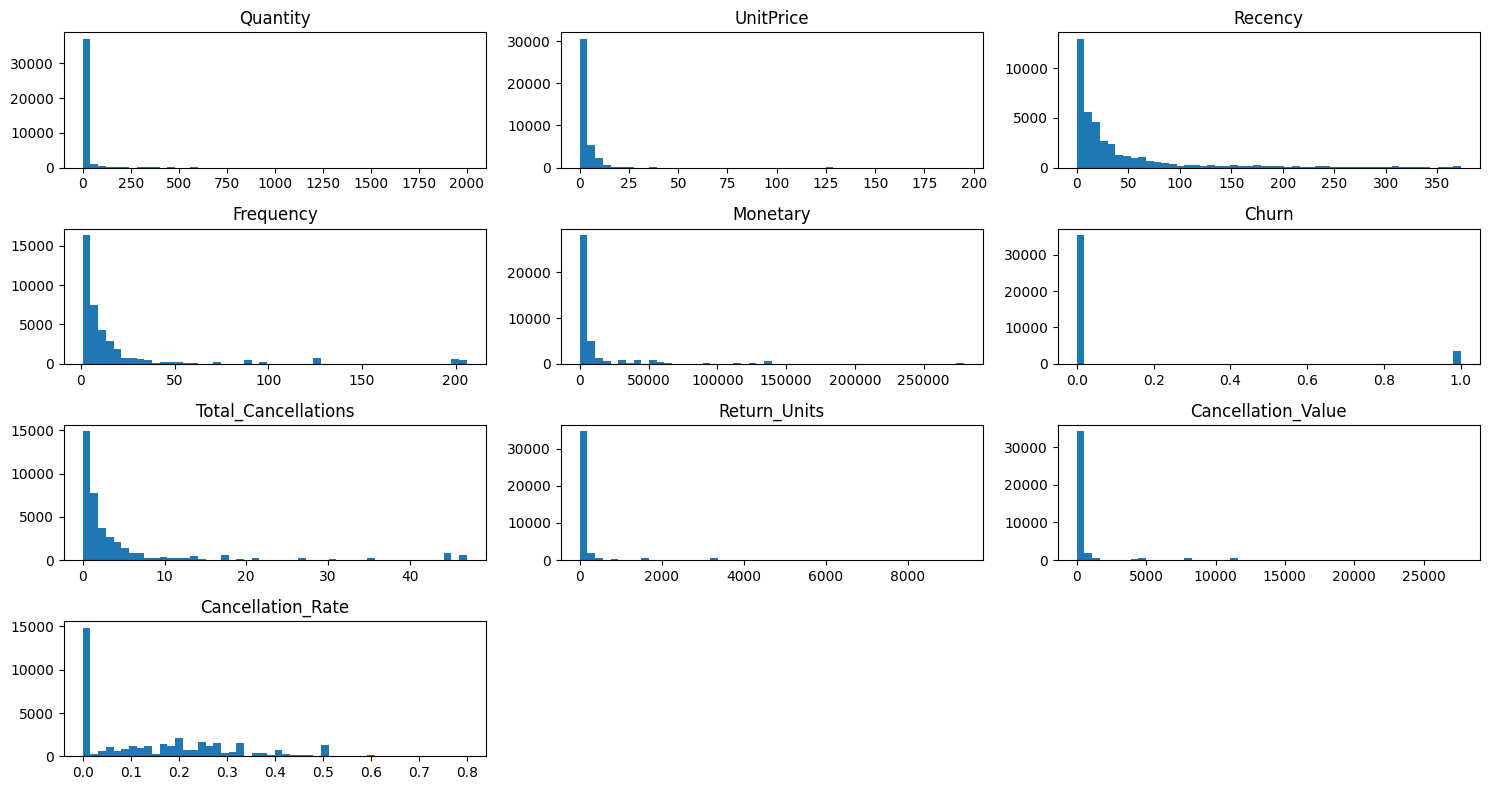

In [ ]:
import matplotlib.pyplot as plt

sample_pd[numeric_cols].hist(
    bins=50,
    figsize=(15, 8),
    grid= False
)

plt.tight_layout()
plt.show()

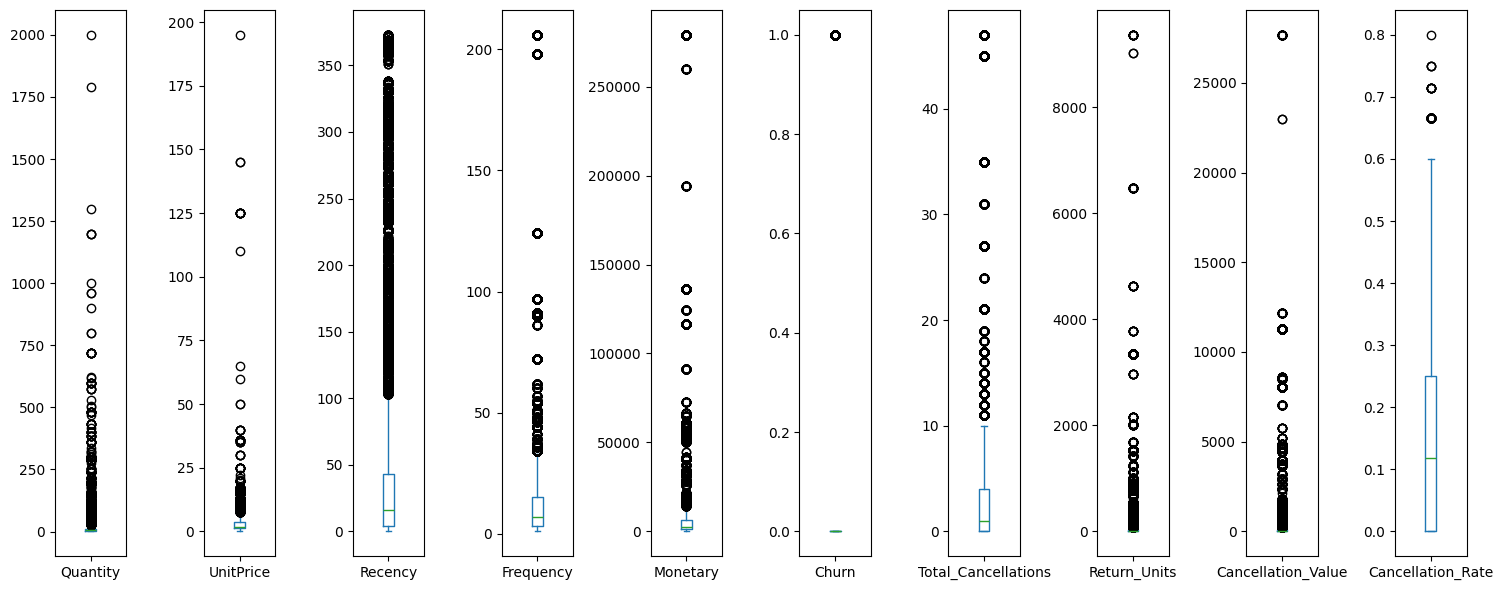

In [ ]:
sample_pd[numeric_cols].plot(
    kind="box",
    subplots=True,
    figsize=(15, 6),
    grid= False
)

plt.tight_layout()
plt.show()

In [ ]:
# create columns for winsorize
winsor_cols = [
    "Frequency",
    "Monetary",
    "Total_Cancellations",
    "Return_Units",
    "Cancellation_Value"
]

In [ ]:
from pyspark.sql import functions as F

def winsorize_spark(
    df,
    columns,
    lower_percentile=0.01,
    upper_percentile=0.99,
    relative_error=0.001
):

    result_df = df
    thresholds = {}

    for col_name in columns:

        # Calculate P1 and P99
        lower, upper = df.approxQuantile(
            col_name,
            [lower_percentile, upper_percentile],
            relative_error
        )

        thresholds[col_name] = {
            "lower": lower,
            "upper": upper
        }

        # Create new winsorized column
        result_df = result_df.withColumn(
            f"{col_name}_winsor",

            F.when(
                F.col(col_name) < lower,
                F.lit(lower)
            )
            .when(
                F.col(col_name) > upper,
                F.lit(upper)
            )
            .otherwise(F.col(col_name))
        )

        print(
            f"{col_name:25s} "
            f"P1 = {lower:.2f} | "
            f"P99 = {upper:.2f}"
        )

    return result_df, thresholds

In [ ]:
customer_winsor_df, thresholds = winsorize_spark(
    final_df,
    winsor_cols,
    lower_percentile=0.01,
    upper_percentile=0.99
)

Frequency                 P1 = 1.00 | P99 = 206.00
Monetary                  P1 = 144.06 | P99 = 136161.83
Total_Cancellations       P1 = 0.00 | P99 = 47.00
Return_Units              P1 = 0.00 | P99 = 3335.00
Cancellation_Value        P1 = 0.00 | P99 = 11252.44


In [ ]:
plot_cols = []

for col_name in winsor_cols:
    plot_cols.extend([
        col_name,
        f"{col_name}_winsor"
    ])

plot_df = (
    customer_winsor_df
    .select(plot_cols)
    .toPandas()
)

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=len(winsor_cols),
    ncols=2,
    figsize=(12, 4 * len(winsor_cols))
)

for i, col_name in enumerate(winsor_cols):

    # BEFORE
    axes[i, 0].boxplot(
        plot_df[col_name].dropna()
    )

    axes[i, 0].set_title(
        f"{col_name} - Before Winsorization"
    )

    axes[i, 0].set_ylabel(col_name)


    # AFTER
    axes[i, 1].boxplot(
        plot_df[f"{col_name}_winsor"].dropna()
    )

    axes[i, 1].set_title(
        f"{col_name} - After Winsorization"
    )

    axes[i, 1].set_ylabel(col_name)


plt.tight_layout()
plt.show()

NameError: name 'winsor_cols' is not defined

In [ ]:
from pathlib import Path

SAVE_PATH = Path(
    "/content/drive/MyDrive/"
    "Dinh Thi Thanh Hang- Portfolio/Data Viz"
)

SAVE_PATH.mkdir(
    parents=True,
    exist_ok=True
)

### Outlier Treatment Approach

- Extreme values were first inspected to distinguish **data errors from valid purchasing behavior**.
- Valid extreme observations were **retained**, as they may represent high-value or bulk-purchasing customers.
- For modeling, highly skewed numerical features such as **Frequency and Monetary** were winsorized at the **1st and 99th percentiles (P1–P99)**.
- Winsorization caps extreme values rather than removing customers, reducing their influence on the model while preserving customer information.
- Original features were retained alongside winsorized versions for comparison and model validation.